# Cafe data EDA to find out the realtion between
* Quantity and Price Per Unit impact on total spend
* Total Spent by Transaction Date
* Total Spent against Location
* Total Spent against Payment Method

# Library we will need

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

## Load data

In [2]:
df = pd.read_csv('clean_cafe_data.csv')
df.head(10)

,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,4,1.0,8.9,Credit Card,In-store,2023-07-19
3,TXN_7034554,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,5,4.0,20.0,Credit Card,UNKNOWN,2023-03-31
6,TXN_4433211,3,3.0,9.0,UNKNOWN,Takeaway,2023-10-06
7,TXN_6699534,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,5,3.0,15.0,UNKNOWN,Takeaway,2023-07-28
9,TXN_2064365,5,4.0,20.0,UNKNOWN,In-store,2023-12-31


In [3]:
df.shape

(10000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Quantity          10000 non-null  int64  
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       10000 non-null  float64
 4   Payment Method    10000 non-null  object 
 5   Location          10000 non-null  object 
 6   Transaction Date  10000 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 547.0+ KB


## Extracted new column from the transaction date, called day of week

In [5]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Day_of_Week'] = df['Transaction Date'].dt.day_name()

In [6]:
df.head(10)

,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day_of_Week
0,TXN_1961373,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday
1,TXN_4977031,4,3.0,12.0,Cash,In-store,2023-05-16,Tuesday
2,TXN_4271903,4,1.0,8.9,Credit Card,In-store,2023-07-19,Wednesday
3,TXN_7034554,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,Thursday
4,TXN_3160411,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday
5,TXN_2602893,5,4.0,20.0,Credit Card,UNKNOWN,2023-03-31,Friday
6,TXN_4433211,3,3.0,9.0,UNKNOWN,Takeaway,2023-10-06,Friday
7,TXN_6699534,4,4.0,16.0,Cash,UNKNOWN,2023-10-28,Saturday
8,TXN_4717867,5,3.0,15.0,UNKNOWN,Takeaway,2023-07-28,Friday
9,TXN_2064365,5,4.0,20.0,UNKNOWN,In-store,2023-12-31,Sunday


In [7]:
df = df[['Quantity' , 'Price Per Unit' ,	'Total Spent' , 'Payment Method' , 'Location' , 'Day_of_Week']]

In [8]:
df.isnull().sum()

Quantity          0
Price Per Unit    0
Total Spent       0
Payment Method    0
Location          0
Day_of_Week       0
dtype: int64

## Lets check quantity and price per unit impact on Total spent

In [9]:
df['Day_of_Week'].value_counts(normalize = True)

Day_of_Week
Monday       0.1453
Friday       0.1448
Sunday       0.1437
Thursday     0.1436
Saturday     0.1432
Wednesday    0.1415
Tuesday      0.1379
Name: proportion, dtype: float64

In [10]:
df['Payment Method'].value_counts(normalize = True)

Payment Method
UNKNOWN           0.3178
Digital Wallet    0.2291
Credit Card       0.2273
Cash              0.2258
Name: proportion, dtype: float64

In [11]:
df['Location'].value_counts(normalize = True)

Location
UNKNOWN     0.3961
Takeaway    0.3022
In-store    0.3017
Name: proportion, dtype: float64

In [12]:
df.describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.00000,10000.000000
mean,3.027100,2.94732,8.923130
std,1.384614,1.24396,5.857115
min,1.000000,1.00000,1.000000
25%,2.000000,2.00000,4.000000
50%,3.000000,3.00000,8.000000
75%,4.000000,4.00000,12.000000
max,5.000000,5.00000,25.000000


## used some plots to identify the outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x248f1157250>,
 'caps': [<matplotlib.lines.Line2D at 0x248f11574d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x248f1157110>],
 'medians': [<matplotlib.lines.Line2D at 0x248f1157750>],
 'fliers': [<matplotlib.lines.Line2D at 0x248f1157890>],
 'means': []}

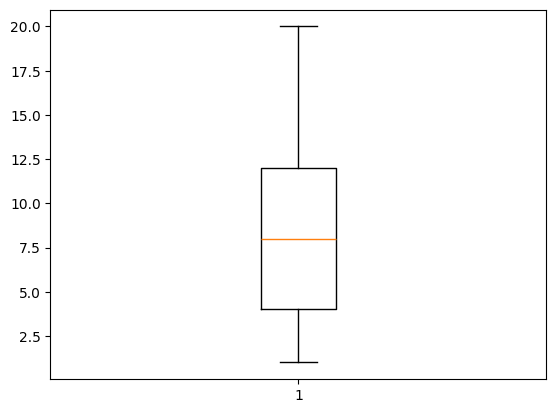

In [24]:
plt.boxplot(df['Total Spent'])

In [19]:
outlier = df[df['Total Quantity'] == 25]
outlier

,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day_of_Week


## As the data is skewed and it is not normalized.
* IQR WILL BE BEST FIT HERE

In [15]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# now it only have data with no outlier
df = df[(df['Total Spent'] >= lower) & (df['Total Spent'] <= upper)]
df

,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day_of_Week
0,2,2.0,4.0,Credit Card,Takeaway,Friday
1,4,3.0,12.0,Cash,In-store,Tuesday
2,4,1.0,8.9,Credit Card,In-store,Wednesday
3,2,5.0,10.0,UNKNOWN,UNKNOWN,Thursday
4,2,2.0,4.0,Digital Wallet,In-store,Sunday
...,...,...,...,...,...,...
9995,2,2.0,4.0,UNKNOWN,UNKNOWN,Wednesday
9996,3,2.9,3.0,Digital Wallet,UNKNOWN,Friday
9997,4,2.0,8.0,Digital Wallet,UNKNOWN,Thursday
9998,3,2.9,3.0,Digital Wallet,UNKNOWN,Saturday


### Exactly 259 row are removed from here which were outlier in Total Spent.

In [25]:
259 /10000 *100

2.59

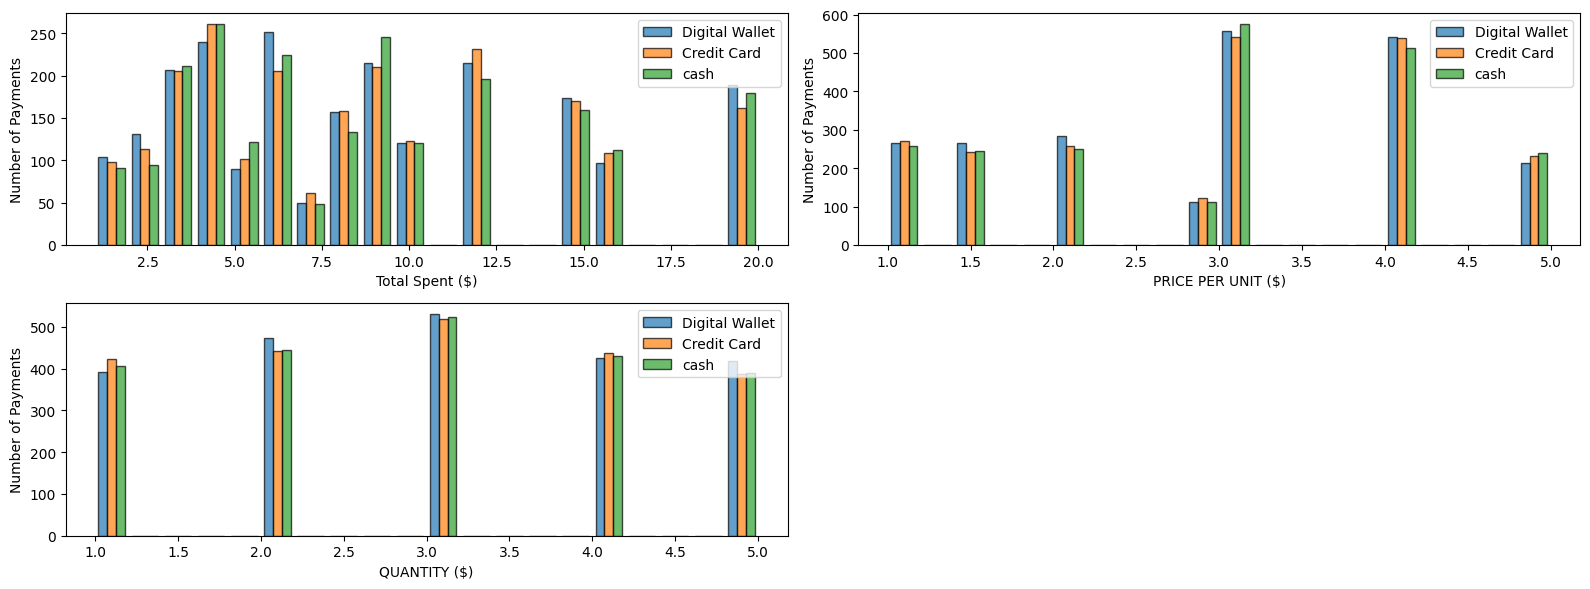

In [79]:
fig, ax = plt.subplots(2,2, figsize=(16,6))

digital = df[df['Payment Method'] == 'Digital Wallet']['Total Spent']
card = df[df['Payment Method'] == 'Credit Card']['Total Spent']
cash = df[df['Payment Method'] == 'Cash']['Total Spent']

digitalprice = df[df['Payment Method'] == 'Digital Wallet']['Price Per Unit']
cardprice = df[df['Payment Method'] == 'Credit Card']['Price Per Unit']
cashprice = df[df['Payment Method'] == 'Cash']['Price Per Unit']

digitalQ = df[df['Payment Method'] == 'Digital Wallet']['Quantity']
cardQ = df[df['Payment Method'] == 'Credit Card']['Quantity']
cashQ = df[df['Payment Method'] == 'Cash']['Quantity']


ax[0,0].hist([digital, card, cash], bins=20, stacked=False, alpha=0.7, 
        label=['Digital Wallet', 'Credit Card', 'cash'], edgecolor='black')

ax[0,0].set_xlabel('Total Spent ($)')
ax[0,0].set_ylabel('Number of Payments')
ax[0,0].legend()

ax[0,1].hist([digitalprice, cardprice, cashprice], bins=20, stacked=False, alpha=0.7, 
        label=['Digital Wallet', 'Credit Card', 'cash'], edgecolor='black')

ax[0,1].set_xlabel('PRICE PER UNIT ($)')
ax[0,1].set_ylabel('Number of Payments')
ax[0,1].legend()

ax[1,0].hist([digitalQ, cardQ, cashQ], bins=20, stacked=False, alpha=0.7, 
        label=['Digital Wallet', 'Credit Card', 'cash'], edgecolor='black')

ax[1,0].set_xlabel('QUANTITY ($)')
ax[1,0].set_ylabel('Number of Payments')
ax[1,0].legend()

ax[1,1].remove()

plt.tight_layout()
plt.show()

## AS there is not significance in payment method, with respect to Quantity , Price per unit or the Total spent
* They almost have similar probability.

In [63]:
df.groupby('Payment Method')['Total Spent'].mean()

Payment Method
Cash              8.612836
Credit Card       8.558986
Digital Wallet    8.584196
UNKNOWN           8.303231
Name: Total Spent, dtype: float64

In [64]:
df.groupby('Payment Method')['Total Spent'].median()

Payment Method
Cash              8.0
Credit Card       8.0
Digital Wallet    8.0
UNKNOWN           8.0
Name: Total Spent, dtype: float64

In [65]:
df.groupby('Payment Method')['Total Spent'].sum()

Payment Method
Cash              18922.4
Credit Card       18906.8
Digital Wallet    19228.6
UNKNOWN           25698.5
Name: Total Spent, dtype: float64